## Checking if $\mathcal{L}\hat{Q}=0$ is satisfied in the updated case

In [ ]:
include("sup_elliptical.jl")
theme(:vibrant)
using LinearAlgebra

---
#### Do an optimisation run and analyse 

In [9]:
v=2
x_leng=3pi/2
y_leng=3pi/2
div = 100
C = sup_opti(x_leng,y_leng,v,div,false,false,1,false,false)

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:  1019932
Number of nonzeros in inequality constraint Jacobian.:    19932
Number of nonzeros in Lagrangian Hessian.............:    57504

Total number of variables............................:   186042
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:   171700
Total number of inequality constraints...............:        1
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        1

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  5.4210109e-20 6.00e-01 2.05e-03  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

([0.0 0.0 … 0.0 0.0; -1.1943575378783755e-25 -2.29853021367167e-25 … -1.0753851707034682e-34 -3.646801423736958e-35; … ; -1.1943355279652469e-25 -2.298487726144124e-25 … -1.0753021850777619e-34 -3.6465197544688873e-35; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 2.1398539490820147e-26 3.9815445232427314e-26 … 2.3498555779469794e-35 6.788105925742522e-36; … ; 2.13968674441314e-26 3.9812254183949626e-26 … 2.3496419490032337e-35 6.787455144949574e-36; 0.0 0.0 … 0.0 0.0], [-4.907780808480755e-24 -9.444979511301866e-24 … -4.418911576275986e-33 -1.498521586005503e-33; -2.5019968915024148e-22 -4.93171275689385e-22 … 5.244780673988856e-19 5.468080250857478e-19; … ; -2.501947702172025e-22 -4.9316156854532405e-22 … 5.2441200459622025e-19 5.467402063492198e-19; -4.9076903674684106e-24 -9.444804923685828e-24 … -4.418565791929867e-33 -1.498405581872527e-33], [8.792956726821284e-25 1.6360718752230794e-24 … 9.655858315402397e-34 2.7893314405211377e-34; 1.845680152907755e-23 3.5135310026497064e-23 … -2.97

In [94]:
n = div+1
dx = C[8]
dy = C[9]
a = x_leng/2
b = y_leng/2
l = x_leng
dt = dx
rhs_t = a + dt 
ymax = round(2*l/sqrt(v^2-1) + l/2,digits=2)
ymin = round(-2*l/sqrt(v^2-1) - l/2,digits=2)

# mod_grad_real = zeros(n,length(C[5]))
# mod_grad_imag = zeros(n,length(C[5]))
# mod_grad = zeros(n,length(C[5]))
lq_real = zeros(n,length(C[5]))
lq_imag = zeros(n,length(C[5]))
lq_rcentre = zeros(n,length(C[5]))
for ti in 1:length(C[5])
    for yi in 1:n
        t = -rhs_t + (ti-1)*dt
        y = -ymax + (yi-1)*dy
        if (t/a)^2 + (y/b)^2 > 1 - dy
            # nothing
        elseif (t/a)^2 + (y/b)^2 > 1- 2*dy && (t/a)^2 + (y/b)^2 <= 1 && y<0 && t<0
            re = ((1-v^2)*second_forw_x(C[1],dx,yi,ti)
                            - 2*v*first_forw_x(C[2],dx,yi,ti) 
                            + second_forw_y(C[1],dy,yi,ti) 
                            + C[1][yi,ti])
            # re = 1
            im = ((1-v^2)*second_forw_x(C[2],dx,yi,ti) 
                            + 2*v*first_forw_x(C[1],dx,yi,ti)
                            + second_forw_y(C[2],dy,yi,ti) 
                            + C[2][yi,ti])
            lq_real[yi,ti] = abs(re)
            lq_imag[yi,ti] = abs(im)
        elseif (t/a)^2 + (y/b)^2 > 1- 2*dy && (t/a)^2 + (y/b)^2 <= 1 && y>=0 && t>=0
            re = ((1-v^2)*second_back_x(C[1],dx,yi,ti)
                            - 2*v*first_back_x(C[2],dx,yi,ti) 
                            + second_back_y(C[1],dy,yi,ti) 
                            + C[1][yi,ti])
            # re=2
            im = ((1-v^2)*second_back_x(C[2],dx,yi,ti) 
                            + 2*v*first_back_x(C[1],dx,yi,ti)
                            + second_back_y(C[2],dy,yi,ti) 
                            + C[2][yi,ti])
            lq_real[yi,ti] = abs(re)
            lq_imag[yi,ti] = abs(im)
        elseif (t/a)^2 + (y/b)^2 > 1- 2*dy && (t/a)^2 + (y/b)^2 <= 1 && y<0 && t>=0
            re = ((1-v^2)*second_back_x(C[1],dx,yi,ti)
                            - 2*v*first_back_x(C[2],dx,yi,ti) 
                            + second_forw_y(C[1],dy,yi,ti) 
                            + C[1][yi,ti])
            # re = 3
            im = ((1-v^2)*second_back_x(C[2],dx,yi,ti) 
                            + 2*v*first_back_x(C[1],dx,yi,ti)
                            + second_forw_y(C[2],dy,yi,ti) 
                            + C[2][yi,ti])
            lq_real[yi,ti] = abs(re)
            lq_imag[yi,ti] = abs(im)
        elseif (t/a)^2 + (y/b)^2 > 1- 2*dy && (t/a)^2 + (y/b)^2 <= 1 && y>=0 && t<0
            re = ((1-v^2)*second_forw_x(C[1],dx,yi,ti)
                            - 2*v*first_forw_x(C[2],dx,yi,ti) 
                            + second_back_y(C[1],dy,yi,ti) 
                            + C[1][yi,ti])
            im = ((1-v^2)*second_forw_x(C[2],dx,yi,ti) 
                            + 2*v*first_forw_x(C[1],dx,yi,ti)
                            + second_back_y(C[2],dy,yi,ti) 
                            + C[2][yi,ti])
            lq_real[yi,ti] = abs(re)
            lq_imag[yi,ti] = abs(im)
        elseif (t/a)^2 + (y/b)^2 <= 1- 2*dy
            re = ((1-v^2)*second_centred_x(C[1],dx,yi,ti)
                            - 2*v*first_centred_x(C[2],dx,yi,ti) 
                            + second_centred_y(C[1],dy,yi,ti) 
                            + C[1][yi,ti])
            # re=0
            im = ((1-v^2)*second_centred_x(C[2],dx,yi,ti) 
                            + 2*v*first_centred_x(C[1],dx,yi,ti)
                            + second_centred_y(C[2],dy,yi,ti) 
                            + C[2][yi,ti])
            lq_real[yi,ti] = abs(re)
            lq_imag[yi,ti] = abs(im)
            lq_rcentre[yi,ti] = abs(re)
        end
    end
end

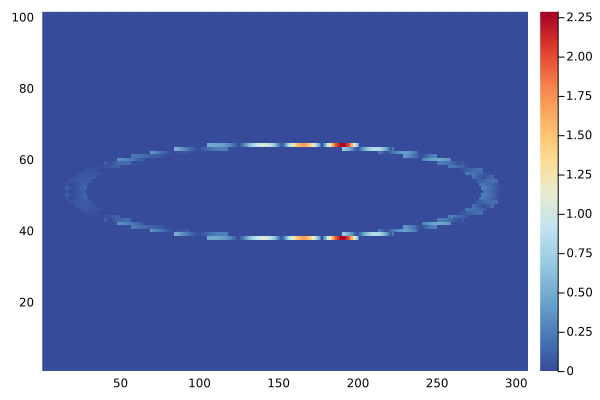

In [95]:
heatmap(lq_real)

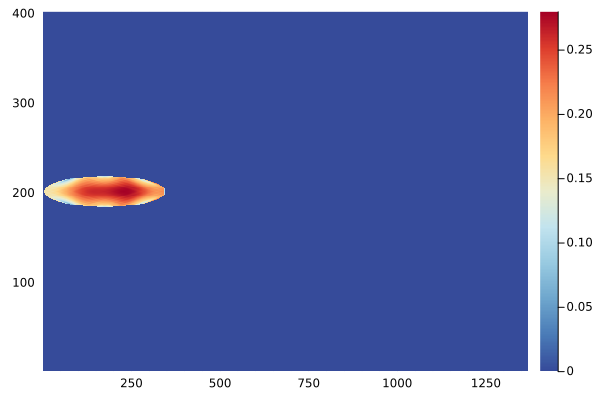

In [76]:
heatmap(A[1])

-----
#### Using data prepared

In [ ]:
using JLD2
data = jldopen("data/sup_v125_1407.jld2")

JLDFile /home/daire/two_dim/2d_code/sign_fixing/sup_v125_1407.jld2 (read-only)
 ├─🔢 info
 ├─🔢 info2
 ├─🔢 C
 ├─🔢 true_xvals
 ├─🔢 true_hr
 └─🔢 r

In [72]:
A = data["C"];
v = 1.25
div = 400

400

#### make $\mathcal{L}\hat{Q}$ check as a function

In [2]:
function lq(C,v)
    n = div+1
    dx = C[8]
    dy = C[9]
    a = x_leng/2
    b = y_leng/2
    l = x_leng
    dt = dx
    rhs_t = a + dt 
    ymax = round(2*l/sqrt(v^2-1) + l/2,digits=2)
    ymin = round(-2*l/sqrt(v^2-1) - l/2,digits=2)

    # mod_grad_real = zeros(n,length(C[5]))
    # mod_grad_imag = zeros(n,length(C[5]))
    # mod_grad = zeros(n,length(C[5]))
    lq_real = zeros(n,length(C[5]))
    lq_imag = zeros(n,length(C[5]))
    lq_rcentre = zeros(n,length(C[5]))
    for ti in 1:length(C[5])
        for yi in 1:n
            t = -rhs_t + (ti-1)*dt
            y = -ymax + (yi-1)*dy
            if (t/a)^2 + (y/b)^2 > 1 - 2dy
                # nothing
            elseif (t/a)^2 + (y/b)^2 > 1- 2*dy && (t/a)^2 + (y/b)^2 <= 1 && y<0 && t<0
                re = ((1-v^2)*second_forw_x(C[1],dx,yi,ti)
                                - 2*v*first_forw_x(C[2],dx,yi,ti) 
                                + second_forw_y(C[1],dy,yi,ti) 
                                + C[1][yi,ti])
                # re = 1
                im = ((1-v^2)*second_forw_x(C[2],dx,yi,ti) 
                                + 2*v*first_forw_x(C[1],dx,yi,ti)
                                + second_forw_y(C[2],dy,yi,ti) 
                                + C[2][yi,ti])
                lq_real[yi,ti] = abs(re)
                lq_imag[yi,ti] = abs(im)
            elseif (t/a)^2 + (y/b)^2 > 1- 2*dy && (t/a)^2 + (y/b)^2 <= 1 && y>=0 && t>=0
                re = ((1-v^2)*second_back_x(C[1],dx,yi,ti)
                                - 2*v*first_back_x(C[2],dx,yi,ti) 
                                + second_back_y(C[1],dy,yi,ti) 
                                + C[1][yi,ti])
                # re=2
                im = ((1-v^2)*second_back_x(C[2],dx,yi,ti) 
                                + 2*v*first_back_x(C[1],dx,yi,ti)
                                + second_back_y(C[2],dy,yi,ti) 
                                + C[2][yi,ti])
                lq_real[yi,ti] = abs(re)
                lq_imag[yi,ti] = abs(im)
            elseif (t/a)^2 + (y/b)^2 > 1- 2*dy && (t/a)^2 + (y/b)^2 <= 1 && y<0 && t>=0
                re = ((1-v^2)*second_back_x(C[1],dx,yi,ti)
                                - 2*v*first_back_x(C[2],dx,yi,ti) 
                                + second_forw_y(C[1],dy,yi,ti) 
                                + C[1][yi,ti])
                # re = 3
                im = ((1-v^2)*second_back_x(C[2],dx,yi,ti) 
                                + 2*v*first_back_x(C[1],dx,yi,ti)
                                + second_forw_y(C[2],dy,yi,ti) 
                                + C[2][yi,ti])
                lq_real[yi,ti] = abs(re)
                lq_imag[yi,ti] = abs(im)
            elseif (t/a)^2 + (y/b)^2 > 1- 2*dy && (t/a)^2 + (y/b)^2 <= 1 && y>=0 && t<0
                re = ((1-v^2)*second_forw_x(C[1],dx,yi,ti)
                                - 2*v*first_forw_x(C[2],dx,yi,ti) 
                                + second_back_y(C[1],dy,yi,ti) 
                                + C[1][yi,ti])
                im = ((1-v^2)*second_forw_x(C[2],dx,yi,ti) 
                                + 2*v*first_forw_x(C[1],dx,yi,ti)
                                + second_back_y(C[2],dy,yi,ti) 
                                + C[2][yi,ti])
                lq_real[yi,ti] = abs(re)
                lq_imag[yi,ti] = abs(im)
            elseif (t/a)^2 + (y/b)^2 <= 1- 2*dy
                re = ((1-v^2)*second_centred_x(C[1],dx,yi,ti)
                                - 2*v*first_centred_x(C[2],dx,yi,ti) 
                                + second_centred_y(C[1],dy,yi,ti) 
                                + C[1][yi,ti])
                # re=0
                im = ((1-v^2)*second_centred_x(C[2],dx,yi,ti) 
                                + 2*v*first_centred_x(C[1],dx,yi,ti)
                                + second_centred_y(C[2],dy,yi,ti) 
                                + C[2][yi,ti])
                lq_real[yi,ti] = abs(re)
                lq_imag[yi,ti] = abs(im)
                lq_rcentre[yi,ti] = abs(re)
            end
        end
    end
    return norm(lq_real,Inf), norm(lq_imag,Inf)
end

lq (generic function with 1 method)

In [3]:
div = 100;
re_dif = [];
im_dif = [];
x_leng = 3pi/2
y_leng = 3pi/2
for v in 1.1:0.05:2.5
    A = sup_opti(x_leng,y_leng,v,div,false,false,1,false,false);
    dif = lq(A,v);
    append!(re_dif,dif[1])
    append!(im_dif,dif[2])
    print(v,"\n")
end



******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:   357000
Number of nonzeros in inequality constraint Jacobian.:     2652
Number of nonzeros in Lagrangian Hessian.............:     7184

Total number of variables............................:    64842
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    63168
Total number of inequality c

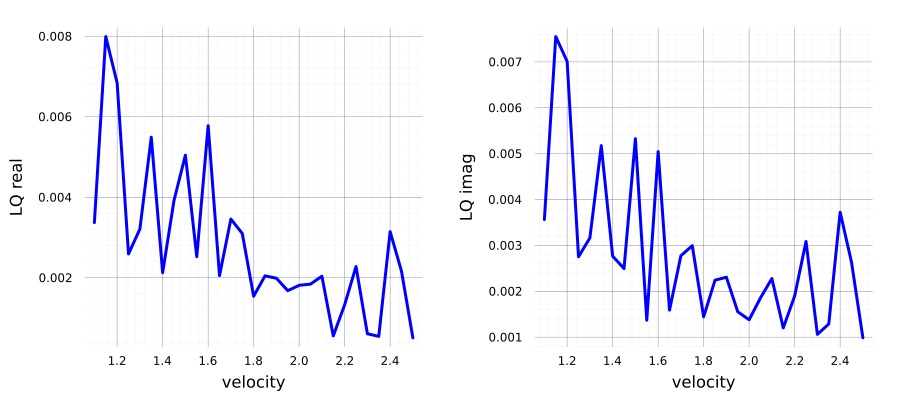

In [15]:
plot(plot(1.1:0.05:2.5,re_dif,ylabel="LQ real"),
        plot(1.1:0.05:2.5,im_dif,ylabel="LQ imag"),
        size=(900,400),xlabel="velocity",margin=0.5Plots.cm,legend=false,
        linewidth=3,linecolor="blue",gridalpha=0.5)

---
$r=\pi/2$ data

In [1]:
using JLD2
using Plots
data = jldopen("data/sup_pi_lq_1808.jld2")

JLDFile /home/daire/shape-considerations-in-wdp/supercritical_elliptical/data/sup_pi_lq_1808.jld2 (read-only)
 ├─🔢 sup_vels
 ├─🔢 re_dif
 ├─🔢 im_dif
 └─🔢 r_cent

In [3]:
sup_vels = data["sup_vels"];
re_dif = data["re_dif"];
im_dif = data["im_dif"];
r_cent = data["r_cent"];

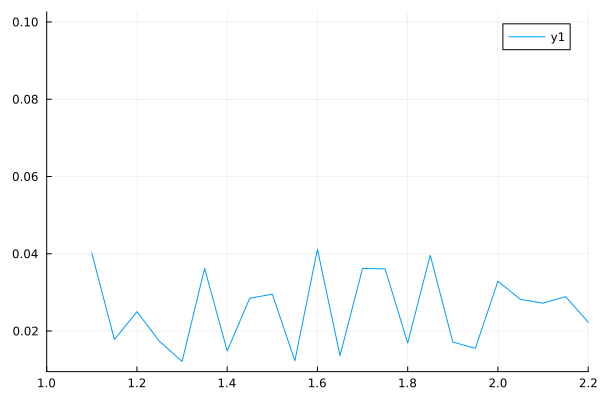

In [5]:
plot(sup_vels, r_cent,xlims=[1,2.2])

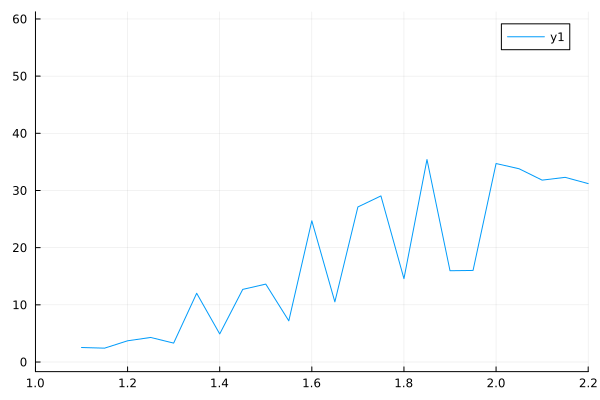

In [6]:
plot(sup_vels, re_dif,xlims=[1,2.2])

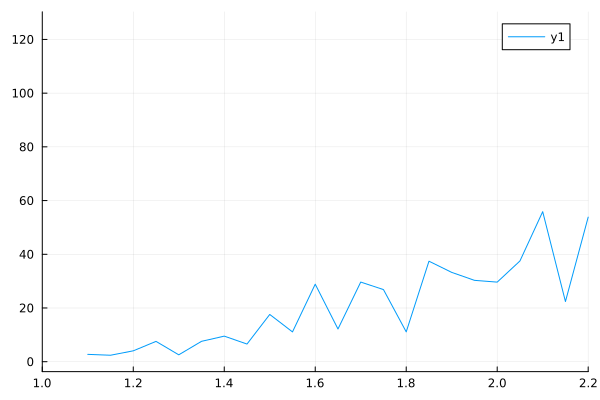

In [7]:
plot(sup_vels, im_dif,xlims=[1,2.2])